# WBC 中華隊賽事 PTT 留言情緒研究：講稿整合版

本 notebook 以「從原始留言資料，逐步整理成可分析、可建模、可解釋的文字分析結果」為主線。

主要流程如下：

1. 讀取與檢查資料  
2. 整理文章與留言欄位  
3. 清理文字並進行中文斷詞  
4. 建立文字特徵：TF-IDF、N-gram、bgram / 文件詞矩陣  
5. 分析詞彙關聯、文章相似度與情緒分布  
6. 建立分類模型、解釋模型結果  
7. 使用主題模型與 N-gram 預測補充研究發現  
8. 匯出可供報告整理的結果

## 0. 環境與套件載入

先確認目前 notebook 使用的 Python 環境，並載入後面會用到的套件。

In [30]:
# =========================
# 0. 本地環境套件確認與載入
# =========================

import sys
import subprocess
import importlib.util

def ensure_package(import_name, pip_name=None):
    """
    檢查套件是否可匯入；若不可匯入，就用目前 notebook 的 Python 安裝。
    """
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"未找到套件 {import_name}，開始安裝 {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pip_name])
    else:
        print(f"已安裝：{import_name}")

core_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("sklearn", "scikit-learn"),
    ("jieba", "jieba"),
    ("wordcloud", "wordcloud"),
    ("networkx", "networkx"),
    ("snownlp", "snownlp"),
    ("openpyxl", "openpyxl"),
    ("ipykernel", "ipykernel"),
]

for import_name, pip_name in core_packages:
    ensure_package(import_name, pip_name)

# =========================
# 1. 正式載入套件
# =========================
import re
import ast
import json
import math
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.decomposition import LatentDirichletAllocation

import jieba
import networkx as nx

try:
    from snownlp import SnowNLP
    HAS_SNOW = True
except Exception:
    HAS_SNOW = False

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except Exception:
    HAS_WORDCLOUD = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
plt.rcParams["font.family"] = ["Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False

print("核心套件載入完成。")
print("SnowNLP available:", HAS_SNOW)
print("WordCloud available:", HAS_WORDCLOUD)


已安裝：numpy
已安裝：pandas
已安裝：matplotlib
已安裝：sklearn
已安裝：jieba
已安裝：wordcloud
已安裝：networkx
已安裝：snownlp
已安裝：openpyxl
已安裝：ipykernel
核心套件載入完成。
SnowNLP available: True
WordCloud available: True


## 1. 讀取資料與基本檢查

這一段是確認資料有沒有成功讀進來，以及欄位名稱、資料筆數、缺值比例是否合理。

資料筆數與欄位數： (7331, 8)


,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip
0,https://www.ptt.cc/bbs/Baseball/M.1771431234.A.EC9.html,[分享] MLB官網列出WBC每隊的關鍵球員,2026/02/19 00:13:52,tty0102,棒球,https://www.mlb.com/news/world-baseball-classic-2026-key-players\n\nMLB官網列出WBC每隊的關鍵球員\n\n這不一定是陣中最強的球員\n\n但很可能左右比賽的勝負...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""u9596g12"", ""cmtContent"": "": 選近藤是因為可能會排在大谷後面嗎"", ""cmtDate"": ""2026-02-19 00:15:00+08:...",49.216.225.131
1,https://www.ptt.cc/bbs/Baseball/M.1771456391.A.BE6.html,[分享] 韓國可能要找O&#39;Brien接替者,2026/02/19 07:13:09,CavendishJr,棒球,https://bit.ly/4aDSrIN\n\n韓國總教練柳志炫說\n\n他接收到的訊息是\n\nO'Brien一週內都很難投球\n\n他可能無法參加\n\n暗示要找人替代\n\n可是O'Brien說他狀況有變好了耶\n\n別太...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""andrew0916"", ""cmtContent"": "": 幸"", ""cmtDate"": ""2026-02-19 07:17:00+08:00""}, {""cmtSt...",27.240.178.209
2,https://www.ptt.cc/bbs/Baseball/M.1771459827.A.BBF.html,Re: [分享] 台灣DAZN 轉播廣島主場,2026/02/19 08:10:25,CrossroadMEI,棒球,※ 引述《YuiiAnitima (唯)》之銘言\n: https://www.threads.com/@dazn_tw/post/DU5SgVPE7c3\n: https://i.imgur.com/sdy9oP3.jpg\n: ...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""rocky9137"", ""cmtContent"": "": 未看先猜有人會揮中國 這裡的中國是日本中國地區 古代"", ""cmtDate"": ""2026-02-19 0...",211.20.87.173


欄位名稱：
['artUrl', 'artTitle', 'artDate', 'artPoster', 'artCatagory', 'artContent', 'artComment', 'e_ip']


,dtype,missing_count,missing_ratio
e_ip,str,81,1.10
artTitle,str,2,0.03


,artDate,artTitle,artCatagory
0,2026-02-19 00:13:52,[分享] MLB官網列出WBC每隊的關鍵球員,棒球
1,2026-02-19 07:13:09,[分享] 韓國可能要找O&#39;Brien接替者,棒球
2,2026-02-19 08:10:25,Re: [分享] 台灣DAZN 轉播廣島主場,棒球


,artCatagory,count
0,棒球,7212
1,MLB,110
2,大型賽事,9


<Figure size 1000x500 with 0 Axes>

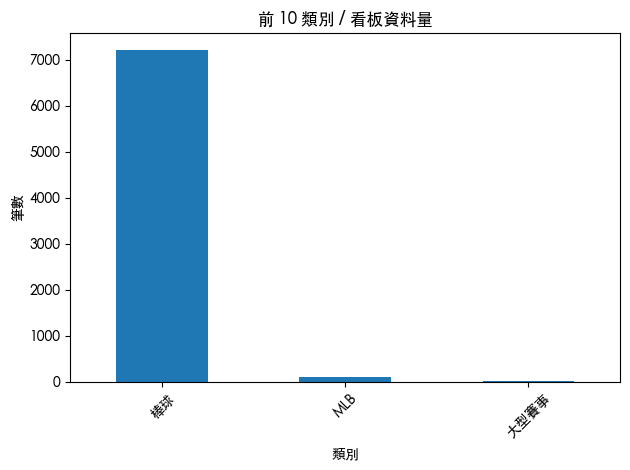

In [31]:
# =========================
# 1. 讀取資料
# =========================
DATA_PATH = "./Data/ptt_wbc.csv"

df = pd.read_csv(DATA_PATH)

print("資料筆數與欄位數：", df.shape)
display(df.head(3))
print("欄位名稱：")
print(df.columns.tolist())

# 檢查缺值與欄位型態
info_df = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_ratio": (df.isna().mean() * 100).round(2)
})

missing_only = info_df[info_df["missing_count"] > 0]
if missing_only.empty:
    print("缺值：無")
else:
    display(missing_only.sort_values("missing_ratio", ascending=False).head(10))

# =========================
# 2. 基本資料整理
# =========================
raw_df = df.copy()

# 日期轉換
raw_df["artDate"] = pd.to_datetime(raw_df["artDate"], errors="coerce")

# 基本文字欄位補空字串，避免後面字串處理報錯
text_cols = ["artTitle", "artContent", "artComment", "artCatagory", "artPoster", "artUrl"]
for col in text_cols:
    if col in raw_df.columns:
        raw_df[col] = raw_df[col].fillna("").astype(str)

display(raw_df[["artDate", "artTitle", "artCatagory"]].head(3))

# 看板 / 類別分布
cat_counts = raw_df["artCatagory"].value_counts().reset_index()
cat_counts.columns = ["artCatagory", "count"]
display(cat_counts.head(5))

plt.figure(figsize=(10, 5))
cat_counts.head(10).plot(kind="bar", x="artCatagory", y="count", legend=False)
plt.title("前 10 類別 / 看板資料量")
plt.xlabel("類別")
plt.ylabel("筆數")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 2. 留言欄位拆解

PTT 資料通常是一篇文章對應多則留言。這裡把 `artComment` 拆開，讓資料變成「一列一則留言」


In [25]:
# =========================
# 3. 留言欄位拆解
# =========================
def parse_comment_list(comment_text):
    """
    將 artComment 欄位從字串轉成 list[dict]。
    這份資料看起來接近 Python literal / JSON 的混合格式，
    因此先用 ast.literal_eval 嘗試解析。
    """
    if not isinstance(comment_text, str) or comment_text.strip() == "":
        return []

    try:
        data = ast.literal_eval(comment_text)
        if isinstance(data, list):
            return data
        return []
    except Exception:
        return []

comment_example = parse_comment_list(raw_df.loc[0, "artComment"])
print("範例留言數：", len(comment_example))
print(comment_example[:2] if len(comment_example) > 0 else "無法解析")

# 把每篇文章的留言展開為多列
records = []

for _, row in raw_df.iterrows():
    comments = parse_comment_list(row["artComment"])
    if len(comments) == 0:
        continue

    for c in comments:
        records.append({
            "artDate": row["artDate"],
            "artTitle": row["artTitle"],
            "artCatagory": row["artCatagory"],
            "artPoster": row["artPoster"],
            "artUrl": row["artUrl"],
            "article_content": row["artContent"],
            "cmtStatus": c.get("cmtStatus", ""),
            "cmtPoster": c.get("cmtPoster", ""),
            "cmtContent": c.get("cmtContent", ""),
            "cmtDate": c.get("cmtDate", "")
        })

comment_df = pd.DataFrame(records)
comment_df["cmtDate"] = pd.to_datetime(comment_df["cmtDate"], errors="coerce")

print("拆解後留言筆數：", comment_df.shape)
display(comment_df.head(3))


範例留言數： 36
[{'cmtStatus': '→', 'cmtPoster': 'u9596g12', 'cmtContent': ': 選近藤是因為可能會排在大谷後面嗎', 'cmtDate': '2026-02-19 00:15:00+08:00'}, {'cmtStatus': '推', 'cmtPoster': 'aa041104', 'cmtContent': ': 希望徐的好表現讓大聯盟後悔沒簽下來', 'cmtDate': '2026-02-19 00:19:00+08:00'}]
拆解後留言筆數： (691342, 10)


,artDate,artTitle,artCatagory,artPoster,artUrl,article_content,cmtStatus,cmtPoster,cmtContent,cmtDate
0,2026-02-19 00:13:52,[分享] MLB官網列出WBC每隊的關鍵球員,棒球,tty0102,https://www.ptt.cc/bbs/Baseball/M.1771431234.A.EC9.html,https://www.mlb.com/news/world-baseball-classic-2026-key-players\n\nMLB官網列出WBC每隊的關鍵球員\n\n這不一定是陣中最強的球員\n\n但很可能左右比賽的勝負...,→,u9596g12,: 選近藤是因為可能會排在大谷後面嗎,2026-02-19 00:15:00+08:00
1,2026-02-19 00:13:52,[分享] MLB官網列出WBC每隊的關鍵球員,棒球,tty0102,https://www.ptt.cc/bbs/Baseball/M.1771431234.A.EC9.html,https://www.mlb.com/news/world-baseball-classic-2026-key-players\n\nMLB官網列出WBC每隊的關鍵球員\n\n這不一定是陣中最強的球員\n\n但很可能左右比賽的勝負...,推,aa041104,: 希望徐的好表現讓大聯盟後悔沒簽下來,2026-02-19 00:19:00+08:00
2,2026-02-19 00:13:52,[分享] MLB官網列出WBC每隊的關鍵球員,棒球,tty0102,https://www.ptt.cc/bbs/Baseball/M.1771431234.A.EC9.html,https://www.mlb.com/news/world-baseball-classic-2026-key-players\n\nMLB官網列出WBC每隊的關鍵球員\n\n這不一定是陣中最強的球員\n\n但很可能左右比賽的勝負...,推,railman,: 徐可以投長局數嗎？,2026-02-19 00:21:00+08:00


## 3. 文字清理與中文斷詞

這一段把原始留言清理成可分析的文字，接著使用 jieba 斷詞，把句子轉成一個一個詞。

,cmtContent,clean_comment
0,: 選近藤是因為可能會排在大谷後面嗎,選近藤是因為可能會排在大谷後面嗎
1,: 希望徐的好表現讓大聯盟後悔沒簽下來,希望徐的好表現讓大聯盟後悔沒簽下來
2,: 徐可以投長局數嗎？,徐可以投長局數嗎
3,: Upper 90應該是95以上的意思？,Upper 90應該是95以上的意思
4,: Upper 90 = high 90s 相對就是low 90s,Upper 90 high 90s 相對就是low 90s


,clean_comment,tokens
0,選近藤是因為可能會排在大谷後面嗎,"[近藤, 可能, 會排, 大谷]"
1,希望徐的好表現讓大聯盟後悔沒簽下來,"[希望, 好表現, 大聯盟後悔, 簽下]"
2,徐可以投長局數嗎,"[投長, 局數]"
3,Upper 90應該是95以上的意思,"[Upper, 應該, 以上, 意思]"
4,Upper 90 high 90s 相對就是low 90s,"[Upper, high, 90s, 相對, low, 90s]"


,token,freq
0,日本,25842
1,台灣,22232
2,韓國,20912
3,澳洲,16328
4,投手,13578
5,還是,10306
6,加油,10246
7,怎麼,10118
8,什麼,10080
9,不要,9968


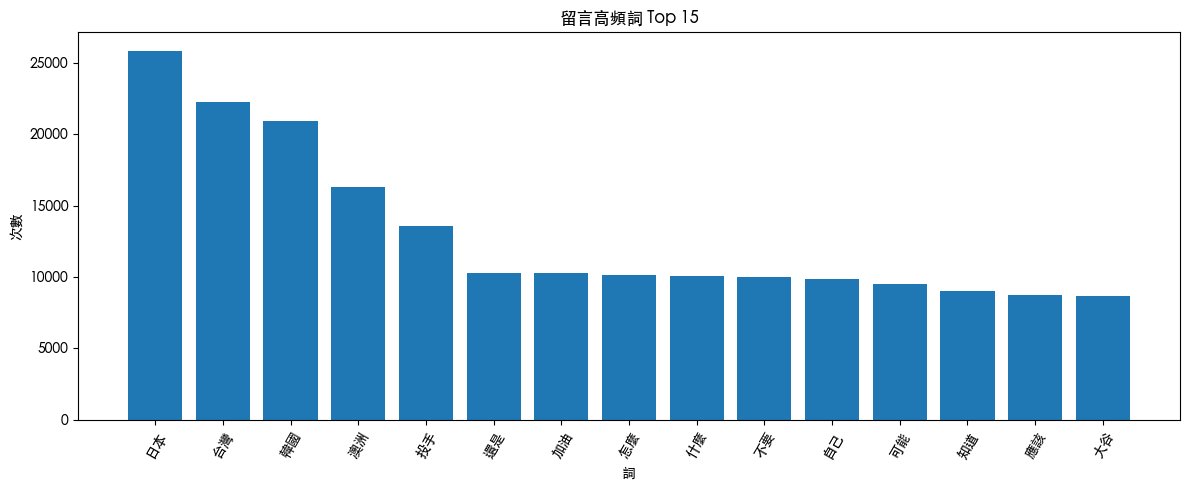

In [32]:
# =========================
# 4. 文字清理
# =========================
STOPWORDS = {
    "的", "了", "是", "在", "就", "都", "而", "及", "與", "和", "或", "很",
    "也", "還", "吧", "啊", "呀", "喔", "欸", "哦", "嗎", "呢", "啦", "有",
    "沒有", "不是", "可以", "這", "那", "一個", "一些", "因為", "所以", "如果",
    "推", "噓", "箭頭", "真的", "感覺", "覺得", "就是", "一下", "目前", "今天",
    "明天", "昨天", "這樣", "那個", "一樣", "大家", "我們", "你們", "他們"
}

# 研究主題相關詞，可視需要加入自訂詞典
custom_words = [
    "中華隊", "中華台北", "王建民", "徐若熙", "陳傑憲", "先發投手", "牛棚投手",
    "全壘打", "守備失誤", "教練團", "關鍵一擊", "世界棒球經典賽", "WBC"
]
for w in custom_words:
    jieba.add_word(w)

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"^\s*:\s*", " ", text)
    text = re.sub(r"[\t]+", " ", text)
    text = re.sub(r"[^0-9A-Za-z一-鿿\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

comment_df["clean_comment"] = comment_df["cmtContent"].astype(str).apply(clean_text)
raw_df["clean_article"] = (raw_df["artTitle"].astype(str) + " " + raw_df["artContent"].astype(str)).apply(clean_text)

display(comment_df[["cmtContent", "clean_comment"]].head(5))

# =========================
# 5. 中文斷詞
# =========================
def tokenize_zh(text):
    """
    使用 jieba 斷詞，再移除停用詞與太短的詞。
    這樣可以保留較有分析價值的詞彙。
    """
    text = clean_text(text)
    words = jieba.lcut(text)

    tokens = []
    for w in words:
        w = w.strip()
        if len(w) <= 1:
            continue
        if w in STOPWORDS:
            continue
        if re.fullmatch(r"\d+", w):
            continue
        tokens.append(w)
    return tokens

comment_df["tokens"] = comment_df["clean_comment"].apply(tokenize_zh)
raw_df["article_tokens"] = raw_df["clean_article"].apply(tokenize_zh)

display(comment_df[["clean_comment", "tokens"]].head(5))

# 看看最常出現的詞
all_comment_tokens = [tok for row in comment_df["tokens"] for tok in row]
token_freq = pd.DataFrame(Counter(all_comment_tokens).most_common(30), columns=["token", "freq"])
display(token_freq.head(10))

plt.figure(figsize=(12, 5))
plt.bar(token_freq["token"][:15], token_freq["freq"][:15])
plt.title("留言高頻詞 Top 15")
plt.xlabel("詞")
plt.ylabel("次數")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


## 4. 文字特徵建立：TF-IDF、N-gram 與 bgram

這一段把文字轉成數字特徵。TF-IDF 用來找代表性關鍵詞，N-gram 用來看常一起出現的詞組，bgram / 文件詞矩陣則是把每則留言轉成機器可以使用的數字表。

,token,mean_tfidf
15348,日本,0.012190
6901,台灣,0.010752
6040,加油,0.010548
29183,韓國,0.010469
18613,澳洲,0.008662
13654,投手,0.006919
2478,不要,0.006162
12170,怎麼,0.005993
1251,xd,0.005873
3470,什麼,0.005821


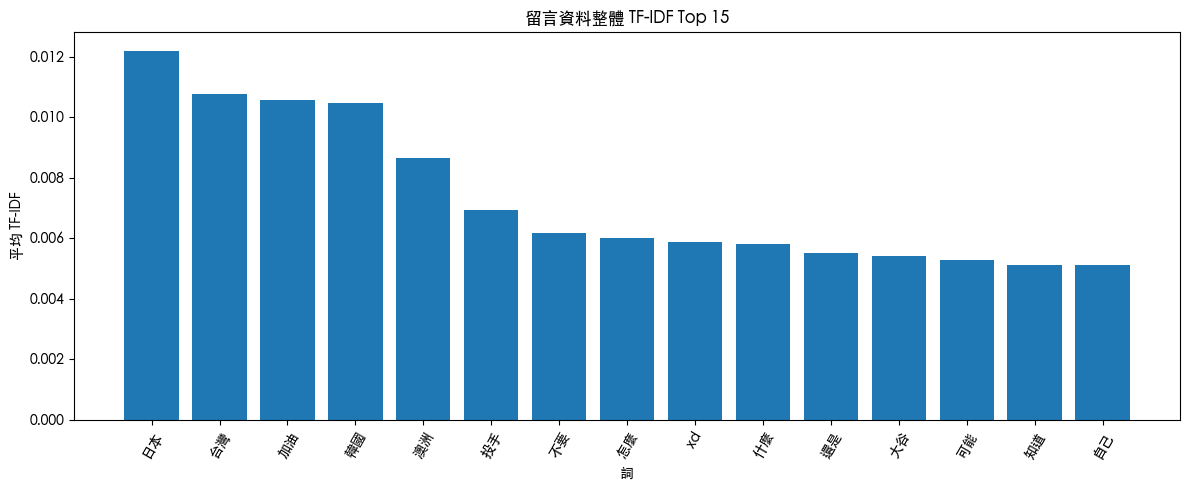

,bigram,freq
0,志在 參加,1644
1,贏韓國 世代,1347
2,怎麼 可能,765
3,神串 留名,755
4,一日 球迷,708
5,委內 瑞拉,628
6,韓國 投手,584
7,澳洲 晉級,550
8,Team Taiwan,531
9,運動家 精神,496


,trigram,freq
0,龍仔 沒事 會合,230
1,韓國隊 留在 東京,195
2,世界 看見 台灣,120
3,謝謝 喜歡 台灣,119
4,to be here,89
5,happy to be,84
6,強隊 不用 算數學,81
7,地獄 死亡 特訓,74
8,費仔 生日 快樂,71
9,發瘋 嚴厲 斥責,70


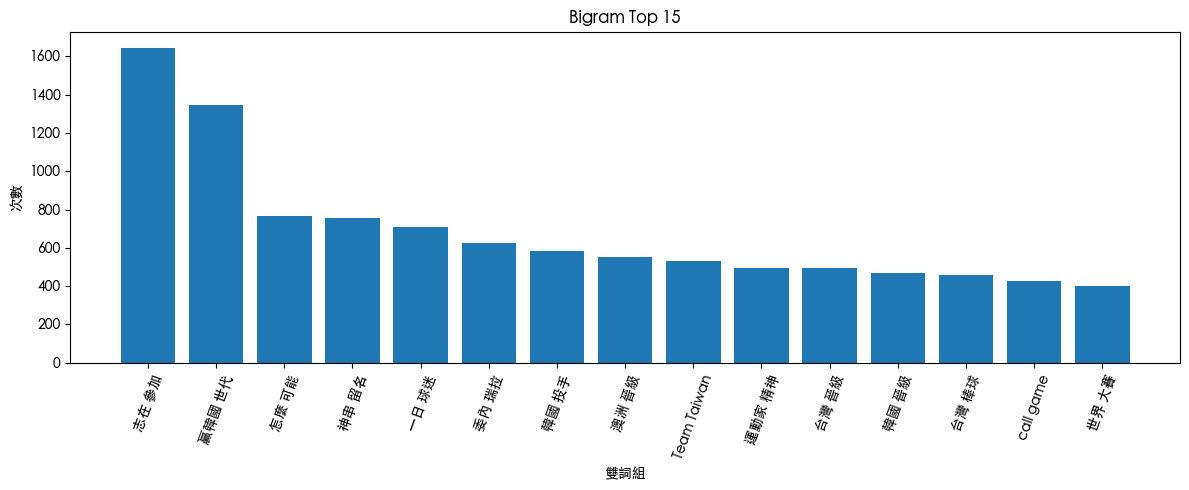

binary_matrix 形狀： (622500, 3000)
詞彙數量： 3000
非零值數量： 1577966
前 5 筆留言各自包含幾個有效詞：


0    3
1    2
2    1
3    3
4    1
Name: 有效詞數, dtype: int64

整體最常出現的 bgram 詞欄位：


,token,doc_count
1598,日本,24955
724,台灣,21716
2921,韓國,20292
1926,澳洲,15712
1437,投手,13227
2752,還是,10208
1290,怎麼,9996
395,什麼,9931
286,不要,9833
631,加油,9805


bgram 預覽：前 3 筆留言 × 前 10 個常見詞


,日本,台灣,韓國,澳洲,投手,還是,怎麼,什麼,不要,加油
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0


In [34]:
# =========================
# 7. TF-IDF
# =========================
# TfidfVectorizer 預設會自己切詞，但中文更適合先斷好詞再用空白串接
def safe_join_tokens(tokens):
    if not isinstance(tokens, (list, tuple, np.ndarray)):
        return ""
    return " ".join(map(str, tokens))


comment_df["token_str"] = comment_df["tokens"].apply(safe_join_tokens)
raw_df["article_token_str"] = raw_df["article_tokens"].apply(safe_join_tokens)

# 避免空字串造成 empty vocabulary
tfidf_docs = comment_df["token_str"].fillna("").str.strip()
tfidf_docs = tfidf_docs[tfidf_docs != ""].reset_index(drop=True)

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,   # 已先斷詞，直接用空白切開
    preprocessor=None,
    token_pattern="",
    max_df=0.9,
    min_df=5,
    dtype=np.float32
)

tfidf_matrix = tfidf_vectorizer.fit_transform(tfidf_docs)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# 計算每個詞在整體語料中的平均 TF-IDF
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

tfidf_rank = pd.DataFrame({
    "token": feature_names,
    "mean_tfidf": mean_tfidf
}).sort_values("mean_tfidf", ascending=False)

display(tfidf_rank.head(10))

plt.figure(figsize=(12, 5))
top_tfidf = tfidf_rank.head(15)
plt.bar(top_tfidf["token"], top_tfidf["mean_tfidf"])
plt.title("留言資料整體 TF-IDF Top 15")
plt.xlabel("詞")
plt.ylabel("平均 TF-IDF")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


# =========================
# 8. Bigram / Trigram
# =========================
def make_ngrams(tokens, n=2):
    if not isinstance(tokens, (list, tuple, np.ndarray)):
        return []
    tokens = list(tokens)

    if len(tokens) < n:
        return []

    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


bigram_counter = Counter()
trigram_counter = Counter()

for toks in comment_df["tokens"]:
    bigram_counter.update(make_ngrams(toks, n=2))
    trigram_counter.update(make_ngrams(toks, n=3))


bigram_df = pd.DataFrame(
    [(" ".join(k), v) for k, v in bigram_counter.most_common(30)],
    columns=["bigram", "freq"]
)

trigram_df = pd.DataFrame(
    [(" ".join(k), v) for k, v in trigram_counter.most_common(30)],
    columns=["trigram", "freq"]
)

display(bigram_df.head(10))
display(trigram_df.head(10))


plt.figure(figsize=(12, 5))
top_bi = bigram_df.head(15)
plt.bar(top_bi["bigram"], top_bi["freq"])
plt.title("Bigram Top 15")
plt.xlabel("雙詞組")
plt.ylabel("次數")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


# =========================
# 9. Binary Bag-of-Words / bgram
# =========================
# 注意：
# 這裡的 bgram 不是 Bigram，而是 Binary Bag-of-Words matrix
# 每一列代表一筆留言，每一欄代表一個詞
# 1 代表該留言有出現該詞，0 代表沒有出現
#
# 因為資料筆數很多，不能把整個 binary_matrix 轉成 pandas DataFrame
# 否則會超過 int32 上限，產生 OverflowError

binary_docs = comment_df["token_str"].fillna("").str.strip()
binary_docs = binary_docs[binary_docs != ""].reset_index(drop=True)

binary_vectorizer = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    binary=True,
    min_df=20,          # 原本 10 太容易產生過多欄位，先提高到 20
    max_df=0.9,
    max_features=3000, # 限制最多保留 3000 個詞，避免矩陣過大
    dtype=np.int8      # binary 只需要 0/1，用 int8 就夠
)

binary_matrix = binary_vectorizer.fit_transform(binary_docs.tolist())
binary_features = np.array(binary_vectorizer.get_feature_names_out())

print("binary_matrix 形狀：", binary_matrix.shape)
print("詞彙數量：", len(binary_features))
print("非零值數量：", binary_matrix.nnz)

# 檢查每篇留言有幾個有效詞
doc_word_count = np.asarray(binary_matrix.sum(axis=1)).ravel()

print("前 5 筆留言各自包含幾個有效詞：")
display(pd.Series(doc_word_count[:5], name="有效詞數"))

# 計算每個詞出現在幾篇留言中
word_doc_count = np.asarray(binary_matrix.sum(axis=0)).ravel()

bgram_summary = pd.DataFrame({
    "token": binary_features,
    "doc_count": word_doc_count
}).sort_values("doc_count", ascending=False)

print("整體最常出現的 bgram 詞欄位：")
display(bgram_summary.head(10))

# 只取前 3 筆、前 10 個常見詞做展示，不要轉整張大表
top_features = bgram_summary.head(10)["token"].to_numpy()

top_feature_indices = [
    np.where(binary_features == token)[0][0]
    for token in top_features
]

bgram_preview = pd.DataFrame(
    binary_matrix[:3, top_feature_indices].toarray(),
    columns=top_features
)

print("bgram 預覽：前 3 筆留言 × 前 10 個常見詞")
display(bgram_preview)


## 5. 詞彙關聯與文章相似度

這一段不只看單一詞的重要性，而是看詞與詞之間是否經常一起出現，以及文章之間在內容上是否相近。

可用留言數： 622500
binary_matrix 形狀： (622500, 800)
保留詞彙數： 800
非零值數量： 1167190
全部可計算詞組數： 319600
corr >= 0.15 且 cooc_count >= 30 的詞組數：3
corr >= 0.10 且 cooc_count >= 30 的詞組數：13
corr >= 0.08 且 cooc_count >= 30 的詞組數：34
corr >= 0.06 且 cooc_count >= 30 的詞組數：76
corr >= 0.04 且 cooc_count >= 30 的詞組數：191
最後保留詞組數： 76


,token_a,token_b,corr,cooc_count
170665,外交,行程,0.203137,98
217025,強隊,算數學,0.192660,101
170602,外交,私人,0.178399,88
189552,委內,瑞拉,0.142384,115
10461,ig,出征,0.126795,118
252067,數學課,體育,0.121201,60
203817,層級,最高,0.119670,66
102026,健康,身體,0.119283,71
239504,技不如人,汪汪,0.113181,104
33706,一支,安打,0.110150,72


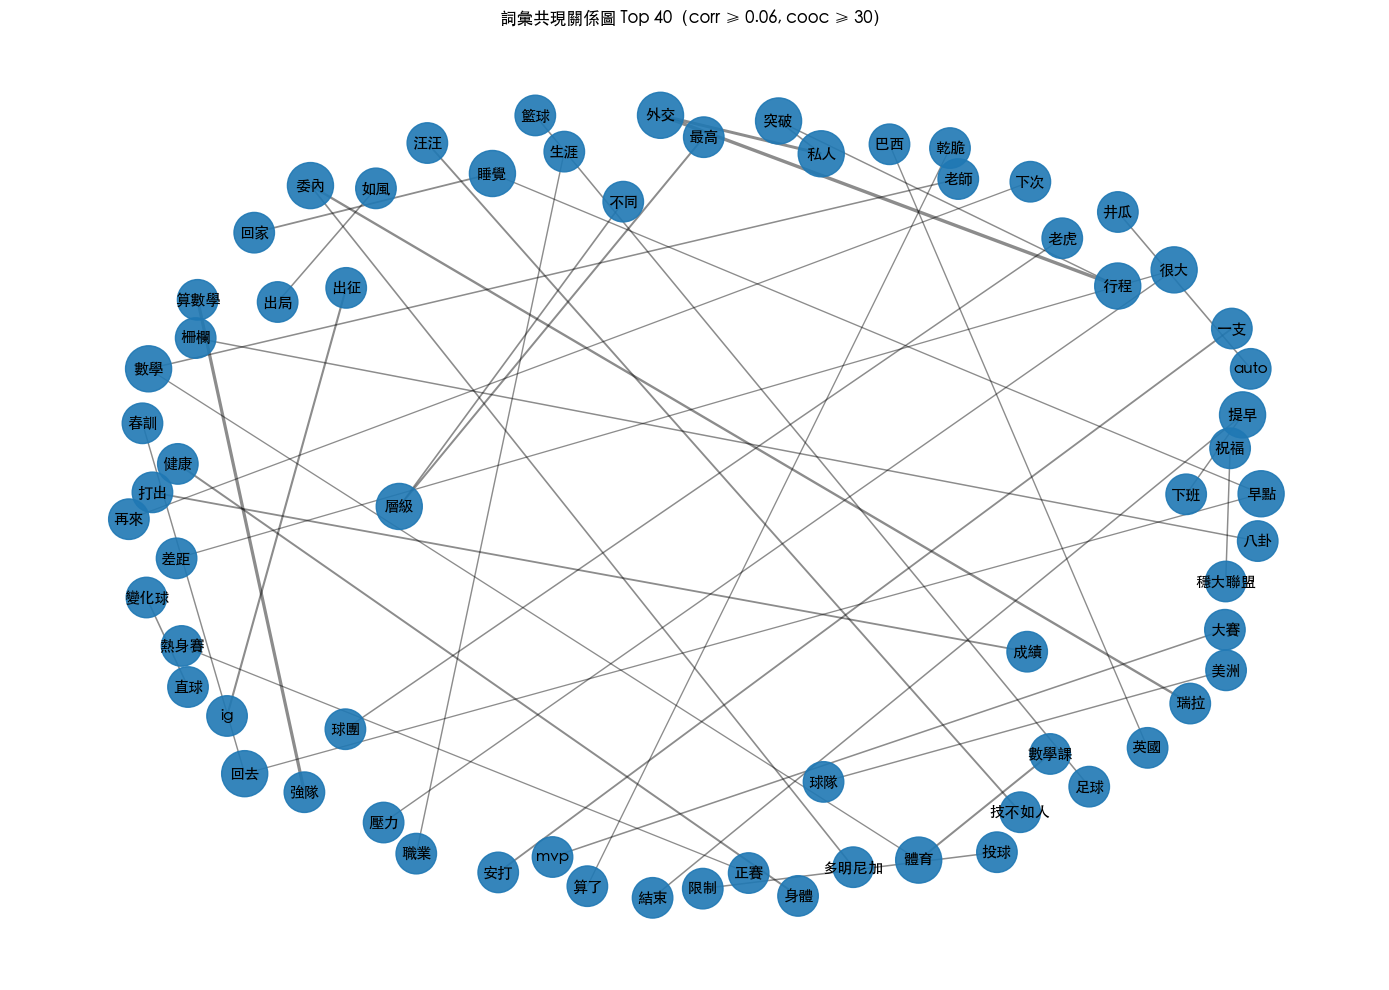

可用文章數： 7331
article_tfidf 形狀： (7331, 33131)
基準文章：


,artDate,artTitle,artCatagory,artUrl
0,2026-02-19 00:13:52,[分享] MLB官網列出WBC每隊的關鍵球員,棒球,https://www.ptt.cc/bbs/Baseball/M.1771431234.A.EC9.html


最相似文章 Top 5：


,artDate,artTitle,artCatagory,artUrl,similarity
555,2026-02-25 10:02:23,[新聞] 運動家正密切關注林維恩,棒球,https://www.ptt.cc/bbs/Baseball/M.1771984946.A.4A3.html,0.371704
1184,2026-03-01 09:58:09,[分享] Griffin 可能成為青少年大聯盟球員,棒球,https://www.ptt.cc/bbs/Baseball/M.1772330312.A.588.html,0.359176
1185,2026-03-01 09:58:47,Fw: [分享] Griffin 可能成為青少年大聯盟球員,MLB,https://www.ptt.cc/bbs/MLB/M.1772330328.A.980.html,0.358890
963,2026-02-27 19:50:28,[分享] 五組人在競標教士隊、開幕前轉賣？,棒球,https://www.ptt.cc/bbs/Baseball/M.1772193033.A.3F2.html,0.344014
6333,2026-03-14 12:50:59,[分享]太空人隨隊記者預測鄧愷威開季牛棚出發,棒球,https://www.ptt.cc/bbs/Baseball/M.1773463861.A.987.html,0.336045


In [38]:
# =========================
# 9. Pairwise correlation / co-occurrence
# =========================
# 目的：
# 找出哪些詞常常在同一則留言中一起出現。
#
# 注意：
# comment_df["token_str"] 已經是「斷詞後用空白串接」的文字，
# 所以這裡不要再用 token_pattern，而是直接用 str.split 切空白。

# 先確保 token_str 存在
if "token_str" not in comment_df.columns:
    comment_df["token_str"] = comment_df["tokens"].apply(safe_join_tokens)

# 避免空字串造成 empty vocabulary
binary_docs = comment_df["token_str"].fillna("").astype(str).str.strip()
binary_docs = binary_docs[binary_docs != ""].reset_index(drop=True)

print("可用留言數：", len(binary_docs))

if len(binary_docs) == 0:
    raise ValueError("binary_docs 是空的，請檢查 comment_df['tokens'] 或 comment_df['token_str'] 是否有成功產生。")

min_df_val = 2 if len(binary_docs) < 200 else 10

# 建立詞-文件矩陣
# binary=True 表示只看這個詞有沒有出現，不看出現幾次
binary_vectorizer = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    binary=True,
    min_df=min_df_val,
    max_df=0.9,
    max_features=800,   # 限制詞數，避免相關矩陣過大
    dtype=np.int8
)

binary_matrix = binary_vectorizer.fit_transform(binary_docs.tolist())
binary_features = np.array(binary_vectorizer.get_feature_names_out())

print("binary_matrix 形狀：", binary_matrix.shape)
print("保留詞彙數：", len(binary_features))
print("非零值數量：", binary_matrix.nnz)

# =========================
# 用稀疏矩陣計算詞與詞共同出現次數
# =========================
# binary_matrix.T @ binary_matrix 會得到：
# 每兩個詞共同出現在幾篇留言中的矩陣
cooc_matrix = (binary_matrix.T @ binary_matrix).astype(np.float64)

# 轉成 array 是安全的，因為前面 max_features=800
# 這裡大小最多是 800 x 800，不是 55 萬 x 800
cooc = cooc_matrix.toarray()

# 每個詞出現在幾篇留言中
word_count = np.asarray(binary_matrix.sum(axis=0)).ravel().astype(np.float64)

# 文件總數
n_docs = binary_matrix.shape[0]

# =========================
# 計算 Phi correlation + 共現次數
# =========================
# corr_threshold：相關係數門檻，越高越嚴格
# min_cooc_count：兩個詞至少要共同出現幾次，避免只出現很少次但相關很高的假關係
# top_n：最後要畫幾組詞彙關係

corr_threshold = 0.06
min_cooc_count = 30
top_n = 40

pairs = []

for i in range(len(binary_features)):
    for j in range(i + 1, len(binary_features)):
        n11 = cooc[i, j]          # 兩個詞都出現的留言數
        n1 = word_count[i]        # token_i 出現的留言數
        n2 = word_count[j]        # token_j 出現的留言數

        denominator = np.sqrt(n1 * n2 * (n_docs - n1) * (n_docs - n2))

        if denominator == 0:
            continue

        phi = (n_docs * n11 - n1 * n2) / denominator

        if np.isfinite(phi):
            pairs.append((binary_features[i], binary_features[j], phi, int(n11)))

all_pair_df = pd.DataFrame(
    pairs,
    columns=["token_a", "token_b", "corr", "cooc_count"]
)

print("全部可計算詞組數：", len(all_pair_df))

# 顯示不同門檻下會剩幾組，方便你判斷門檻是否太嚴格
for t in [0.15, 0.10, 0.08, 0.06, 0.04]:
    count_t = ((all_pair_df["corr"] >= t) & (all_pair_df["cooc_count"] >= min_cooc_count)).sum()
    print(f"corr >= {t:.2f} 且 cooc_count >= {min_cooc_count} 的詞組數：{count_t}")

# 實際要拿來畫圖的資料
pair_df = all_pair_df[
    (all_pair_df["corr"] >= corr_threshold) &
    (all_pair_df["cooc_count"] >= min_cooc_count)
].sort_values(["corr", "cooc_count"], ascending=False)

print("最後保留詞組數：", len(pair_df))

if pair_df.empty:
    print("沒有找到符合門檻的詞彙組合，請降低 corr_threshold 或 min_cooc_count。")
else:
    display(pair_df.head(30))


# =========================
# 畫出詞彙關係圖
# =========================
top_pairs = pair_df.head(top_n)

G = nx.Graph()

for _, row in top_pairs.iterrows():
    G.add_edge(
        row["token_a"],
        row["token_b"],
        weight=row["corr"],
        cooc_count=row["cooc_count"]
    )

plt.figure(figsize=(14, 10))

if len(G.nodes) > 0:
    font_family = None
    if isinstance(plt.rcParams.get("font.family"), (list, tuple)) and plt.rcParams["font.family"]:
        font_family = plt.rcParams["font.family"][0]
    elif isinstance(plt.rcParams.get("font.family"), str):
        font_family = plt.rcParams["font.family"]

    pos = nx.spring_layout(G, seed=42, k=0.8)

    # 線越粗，代表相關越強
    weights = [G[u][v]["weight"] * 12 for u, v in G.edges()]

    # 節點大小依照 degree 調整：連到越多詞，節點越大
    degrees = dict(G.degree())
    node_sizes = [600 + degrees[node] * 250 for node in G.nodes()]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G,
        pos,
        width=weights,
        alpha=0.45
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=11,
        font_family=font_family
    )

    plt.title(f"詞彙共現關係圖 Top {top_n}（corr ≥ {corr_threshold}, cooc ≥ {min_cooc_count}）")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("目前沒有足夠的詞彙關聯可視化。")


# =========================
# 10. 文章相似度分析
# =========================
# 目的：
# 使用文章內容的 TF-IDF 向量，找出與指定文章最相似的其他文章。
#
# 注意：
# article_token_str 也是已斷詞後用空白串接，
# 所以一樣使用 tokenizer=str.split，不使用 token_pattern。

if "article_token_str" not in raw_df.columns:
    raw_df["article_token_str"] = raw_df["article_tokens"].apply(safe_join_tokens)

article_docs = raw_df["article_token_str"].fillna("").astype(str).str.strip()

# 保留非空文章，並保留原本 index，方便回頭對應 raw_df
valid_article_mask = article_docs != ""
valid_article_docs = article_docs[valid_article_mask]
valid_article_indices = valid_article_docs.index.to_numpy()

print("可用文章數：", len(valid_article_docs))

if len(valid_article_docs) < 2:
    print("可用文章數不足，先略過文章相似度分析。")
else:
    article_vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        max_df=0.9,
        min_df=2,
        dtype=np.float32
)

    article_tfidf = article_vectorizer.fit_transform(valid_article_docs.tolist())

    print("article_tfidf 形狀：", article_tfidf.shape)

    # 顯示第 0 篇有效文章最相似的前幾篇
    base_pos = 0
    base_raw_idx = valid_article_indices[base_pos]

    # 不要一次算完整 similarity_matrix
# 只算指定文章對全部文章的相似度，避免矩陣過大
    sim_scores = cosine_similarity(article_tfidf[base_pos], article_tfidf).ravel()

    similar_pos = np.argsort(sim_scores)[::-1]

    # 排除自己
    similar_pos = similar_pos[similar_pos != base_pos]

    # 取前 5 篇
    top_similar_pos = similar_pos[:5]
    top_raw_indices = valid_article_indices[top_similar_pos]

    similar_articles = raw_df.loc[
        top_raw_indices,
        ["artDate", "artTitle", "artCatagory", "artUrl"]
    ].copy()

    similar_articles["similarity"] = sim_scores[top_similar_pos]

    print("基準文章：")
    display(raw_df.loc[[base_raw_idx], ["artDate", "artTitle", "artCatagory", "artUrl"]])

    print("最相似文章 Top 5：")
    display(similar_articles)


## 6. 情緒分析與文字雲

這一段把留言轉成情緒分數，觀察留言整體偏正向或負向，並保留文字雲作為報告展示用圖。

情緒分析抽樣 5000 筆留言以加速運算。


,clean_comment,sentiment,sentiment_label
46607,這是全場球只看半局是吧,0.458186,neutral
566035,笑死,0.491369,neutral
454838,現在看 澳洲那場主審影響超大,0.966143,positive
611591,最好那時候不揮棒是對國家最有幫助,0.723292,positive
314441,訓練就是自律的問題,0.123407,negative


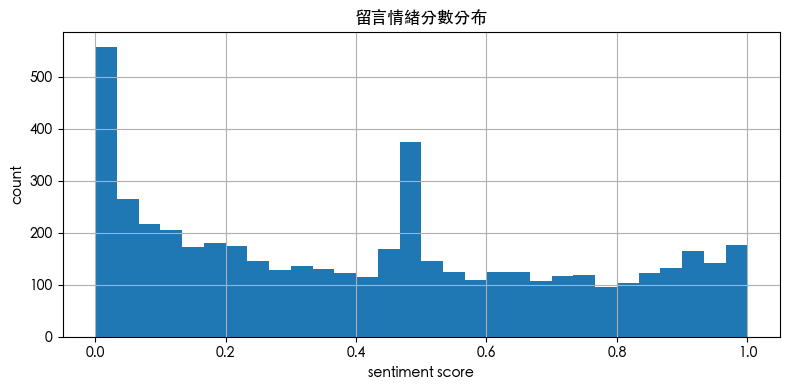

sentiment_label
negative    2439
positive    1525
neutral     1036
Name: count, dtype: int64

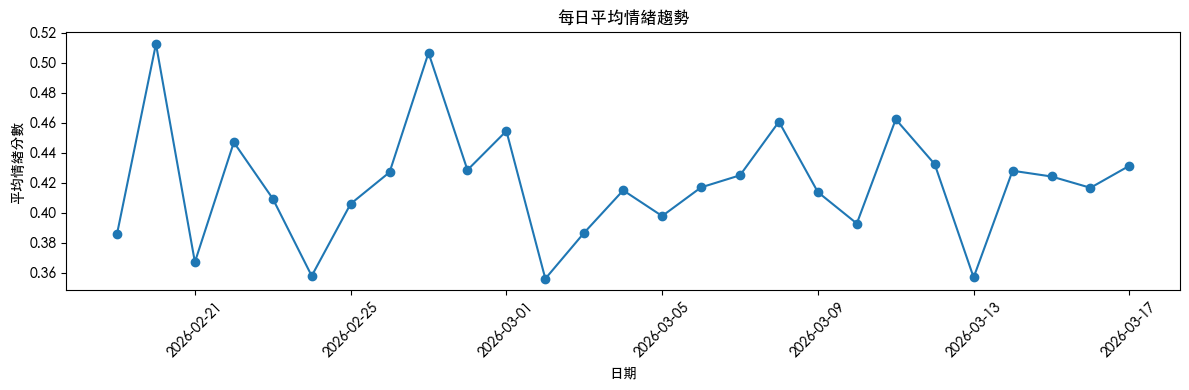

目前使用的文字雲字型： /System/Library/Fonts/STHeiti Medium.ttc


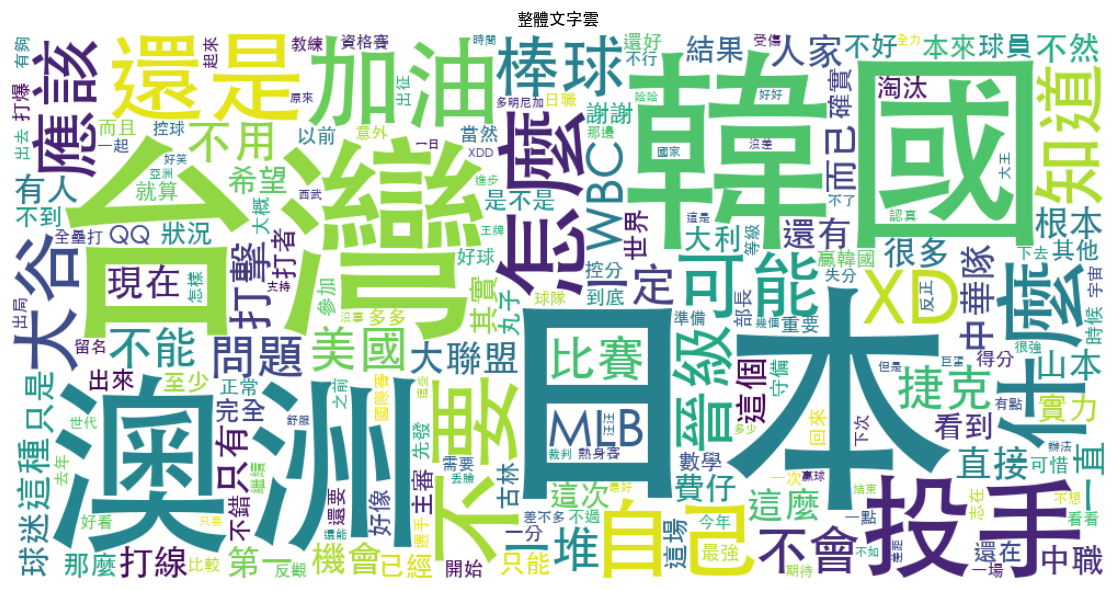

In [40]:
# =========================
# 11. 情緒分析
# =========================
if HAS_SNOW:
    def get_sentiment(text):
        text = str(text).strip()
        if text == "":
            return np.nan
        try:
            return SnowNLP(text).sentiments
        except Exception:
            return np.nan

    # 先只取一定長度以上留言，避免太短句子造成噪音過大
    senti_df = comment_df.copy()
    senti_df["text_len"] = senti_df["clean_comment"].str.len()
    senti_df = senti_df[senti_df["text_len"] >= 2].copy()

    MAX_SENTI = 5000
    if len(senti_df) > MAX_SENTI:
        senti_df = senti_df.sample(n=MAX_SENTI, random_state=42)
        print(f"情緒分析抽樣 {MAX_SENTI} 筆留言以加速運算。")
    else:
        print(f"情緒分析使用全部留言，共 {len(senti_df)} 筆。")

    senti_df["sentiment"] = senti_df["clean_comment"].apply(get_sentiment)

    # 分類：可依研究需求調整門檻
    def label_sentiment(x):
        if pd.isna(x):
            return "unknown"
        if x >= 0.6:
            return "positive"
        elif x <= 0.4:
            return "negative"
        return "neutral"

    senti_df["sentiment_label"] = senti_df["sentiment"].apply(label_sentiment)

    display(senti_df[["clean_comment", "sentiment", "sentiment_label"]].head(5))

    plt.figure(figsize=(8, 4))
    senti_df["sentiment"].dropna().hist(bins=30)
    plt.title("留言情緒分數分布")
    plt.xlabel("sentiment score")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    display(senti_df["sentiment_label"].value_counts())
else:
    print("目前環境未安裝 SnowNLP。")
    print("可先執行：!pip install snownlp")

# 不同日期的情緒趨勢（如果 SnowNLP 可用）
if HAS_SNOW and len(senti_df) > 0:
    senti_df["comment_date_only"] = pd.to_datetime(senti_df["cmtDate"], errors="coerce").dt.date
    daily_sentiment = senti_df.groupby("comment_date_only")["sentiment"].mean().reset_index()

    plt.figure(figsize=(12, 4))
    plt.plot(daily_sentiment["comment_date_only"], daily_sentiment["sentiment"], marker="o")
    plt.title("每日平均情緒趨勢")
    plt.xlabel("日期")
    plt.ylabel("平均情緒分數")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =========================
# 12. 文字雲（可選）
# =========================
# 注意：中文字雲通常需要指定中文字型路徑
# 例如 Windows 可用：
candidate_font_paths = [
    "/System/Library/Fonts/PingFang.ttc",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/System/Library/Fonts/Supplemental/Songti.ttc",
    "/System/Library/Fonts/Supplemental/Heiti TC.ttc",
]

font_path = None

for path in candidate_font_paths:
    if os.path.exists(path):
        font_path = path
        break

print("目前使用的文字雲字型：", font_path)

if not HAS_WORDCLOUD:
    print("目前環境未安裝 wordcloud。")
    print("請先執行：!pip install wordcloud")
elif font_path is None:
    print("找不到可用中文字型，請手動設定 font_path。")
else:
    # all_comment_tokens 是前面整理好的所有留言斷詞結果
    text_for_cloud = " ".join(map(str, all_comment_tokens))

    if text_for_cloud.strip() == "":
        print("文字雲資料是空的，請檢查 all_comment_tokens 是否有內容。")
    else:
        wc = WordCloud(
            width=1000,
            height=500,
            background_color="white",
            font_path=font_path,
            collocations=False
        ).generate(text_for_cloud)

        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title("整體文字雲")
        plt.tight_layout()
        plt.show()

## 7. 分類模型與預測比較

這一段把前面產生的文字特徵與情緒標籤拿來訓練分類模型，並比較哪個模型預測表現較好。

情緒標籤分布：


,sentiment_label,count
0,negative,2345
1,positive,1482
2,neutral,919


模型比較結果：


,模型,測試集 Accuracy,測試集 Macro F1,交叉驗證 Accuracy,交叉驗證 Macro F1
0,LinearSVC,0.550526,0.527981,0.518753,0.494570
1,LogisticRegression,0.529474,0.511783,0.509692,0.491762
2,ComplementNB,0.535789,0.468597,0.536241,0.460593
3,Dummy 基準模型,0.493684,0.220343,0.494100,0.220467


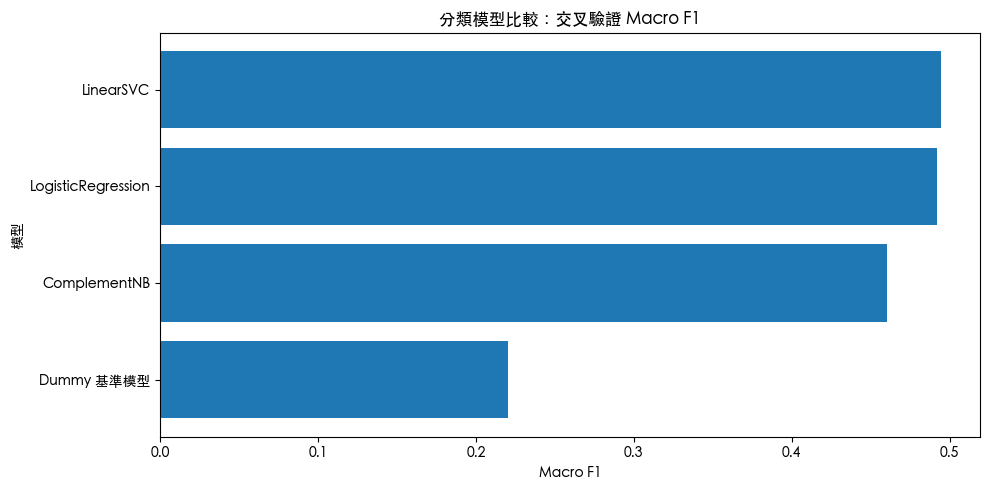

最佳模型：LinearSVC
測試集 Accuracy：0.551
測試集 Macro F1：0.528


,precision,recall,f1-score,support
positive,0.562500,0.454545,0.502793,297.000000
neutral,0.354305,0.581522,0.440329,184.000000
negative,0.688725,0.599147,0.640821,469.000000
accuracy,0.550526,0.550526,0.550526,0.550526
macro avg,0.535177,0.545071,0.527981,950.000000
weighted avg,0.584491,0.550526,0.558837,950.000000


混淆矩陣：


,預測 positive,預測 neutral,預測 negative
實際 positive,135,83,79
實際 neutral,29,107,48
實際 negative,76,112,281


可解釋模型：LinearSVC
各情緒類別最具影響力的關鍵詞：


,情緒類別,排名,關鍵詞,影響係數
0,negative,1,問題,2.581445
1,negative,2,機會,2.055811
2,negative,3,沒差,1.826603
3,negative,4,不會,1.794899
4,negative,5,時間,1.658321
5,negative,6,那麼,1.647445
6,negative,7,台灣,1.611343
7,negative,8,球衣,1.564211
8,negative,9,完蛋,1.540196
9,negative,10,怎樣,1.538591


In [45]:
# =========================
# 13. 分類模型：情緒預測模型比較
# =========================
# 目的：
# 使用前面 SnowNLP 產生的 sentiment_label 作為標籤，
# 比較不同文字分類模型預測留言情緒的效果。
#
# 說明：
# 這裡的情緒標籤來自 SnowNLP 自動判斷，
# 因此本段重點是比較不同分類模型的表現，
# 並觀察哪些詞會影響模型判斷。

import warnings
warnings.filterwarnings("ignore")

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

best_model_name = None
best_model = None
fitted_models = {}

if HAS_SNOW:
    model_df = senti_df[
        senti_df["sentiment_label"].isin(["positive", "neutral", "negative"])
    ].copy()

    model_df = model_df[model_df["clean_comment"].astype(str).str.len() >= 2].copy()

    # 確保 token_str 存在
    if "token_str" not in model_df.columns:
        if "tokens" in model_df.columns:
            model_df["token_str"] = model_df["tokens"].apply(safe_join_tokens)
        else:
            raise ValueError("缺少 token_str 或 tokens，請確認前面的斷詞流程是否完成。")

    model_df["token_str"] = model_df["token_str"].fillna("").astype(str).str.strip()
    model_df = model_df[model_df["token_str"] != ""].copy()

    label_counts = model_df["sentiment_label"].value_counts()

    print("情緒標籤分布：")
    display(label_counts.rename_axis("sentiment_label").reset_index(name="count"))

    if len(model_df) < 50 or label_counts.min() < 2:
        print("可用情緒標籤資料不足，略過分類模型。")
    else:
        MAX_MODEL = 12000
        if len(model_df) > MAX_MODEL:
            model_df = model_df.sample(n=MAX_MODEL, random_state=42)

        X = model_df["token_str"]
        y = model_df["sentiment_label"]

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        def make_tfidf(ngram_range=(1, 1), max_features=20000):
            return TfidfVectorizer(
                tokenizer=str.split,
                preprocessor=None,
                token_pattern=None,
                ngram_range=ngram_range,
                min_df=2,
                max_df=0.9,
                max_features=max_features,
                sublinear_tf=True
            )

        models = {
            "Dummy 基準模型": Pipeline([
                ("tfidf", make_tfidf()),
                ("clf", DummyClassifier(strategy="most_frequent"))
            ]),

            "ComplementNB": Pipeline([
                ("tfidf", make_tfidf()),
                ("clf", ComplementNB())
            ]),

            "LogisticRegression": Pipeline([
                ("tfidf", make_tfidf(ngram_range=(1, 2), max_features=30000)),
                ("clf", LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced"
                ))
            ]),

            "LinearSVC": Pipeline([
                ("tfidf", make_tfidf(ngram_range=(1, 2), max_features=30000)),
                ("clf", LinearSVC(
                    class_weight="balanced",
                    max_iter=5000
                ))
            ])
        }

        # 依照最少類別數，自動決定交叉驗證折數
        min_class_count = y.value_counts().min()
        cv_splits = min(3, min_class_count)

        cv = StratifiedKFold(
            n_splits=cv_splits,
            shuffle=True,
            random_state=42
        )

        results = []

        for name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            test_acc = accuracy_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred, average="macro")

            # 使用 n_jobs=1，避免 VS Code / Jupyter debug subprocess 訊息干擾輸出
            cv_scores = cross_validate(
                model,
                X,
                y,
                cv=cv,
                scoring=["accuracy", "f1_macro"],
                n_jobs=1
            )

            results.append({
                "模型": name,
                "測試集 Accuracy": test_acc,
                "測試集 Macro F1": test_f1,
                "交叉驗證 Accuracy": cv_scores["test_accuracy"].mean(),
                "交叉驗證 Macro F1": cv_scores["test_f1_macro"].mean()
            })

            fitted_models[name] = model

        result_df = pd.DataFrame(results).sort_values(
            ["交叉驗證 Macro F1", "測試集 Macro F1", "測試集 Accuracy"],
            ascending=False
        ).reset_index(drop=True)

        print("模型比較結果：")
        display(result_df)

        plt.figure(figsize=(10, 5))
        plot_df = result_df.sort_values("交叉驗證 Macro F1", ascending=True)

        plt.barh(plot_df["模型"], plot_df["交叉驗證 Macro F1"])
        plt.title("分類模型比較：交叉驗證 Macro F1")
        plt.xlabel("Macro F1")
        plt.ylabel("模型")
        plt.tight_layout()
        plt.show()

        best_model_name = result_df.iloc[0]["模型"]
        best_model = fitted_models[best_model_name]

        y_pred = best_model.predict(X_test)

        print(f"最佳模型：{best_model_name}")
        print(f"測試集 Accuracy：{accuracy_score(y_test, y_pred):.3f}")
        print(f"測試集 Macro F1：{f1_score(y_test, y_pred, average='macro'):.3f}")

        label_order = ["positive", "neutral", "negative"]

        report = classification_report(
            y_test,
            y_pred,
            labels=label_order,
            output_dict=True,
            zero_division=0
        )

        report_df = pd.DataFrame(report).T
        display(report_df.loc[label_order + ["accuracy", "macro avg", "weighted avg"]])

        cm = confusion_matrix(y_test, y_pred, labels=label_order)

        cm_df = pd.DataFrame(
            cm,
            index=["實際 positive", "實際 neutral", "實際 negative"],
            columns=["預測 positive", "預測 neutral", "預測 negative"]
        )

        print("混淆矩陣：")
        display(cm_df)

else:
    print("目前沒有 SnowNLP 情緒標籤，因此略過分類模型。")


# =========================
# 14. 可解釋模型結果：關鍵詞分析
# =========================
# 目的：
# 如果最佳模型是線性模型，則可以觀察哪些詞最容易影響情緒分類。

if HAS_SNOW and best_model is not None:
    clf = best_model.named_steps["clf"]
    tfidf = best_model.named_steps["tfidf"]

    if hasattr(clf, "coef_"):
        feature_names = np.array(tfidf.get_feature_names_out())
        classes = clf.classes_

        print(f"可解釋模型：{best_model_name}")

        explanation_rows = []

        for idx, cls in enumerate(classes):
            coef = clf.coef_[idx]

            top_pos_idx = np.argsort(coef)[-10:][::-1]

            for rank, feature_idx in enumerate(top_pos_idx, start=1):
                explanation_rows.append({
                    "情緒類別": cls,
                    "排名": rank,
                    "關鍵詞": feature_names[feature_idx],
                    "影響係數": coef[feature_idx]
                })

        explanation_df = pd.DataFrame(explanation_rows)

        print("各情緒類別最具影響力的關鍵詞：")
        display(explanation_df)

    else:
        print(f"{best_model_name} 無法直接用係數解釋關鍵詞。")

## 8. 主題模型與 N-gram 預測

這一段用 LDA 主題模型整理留言背後的討論主題；LDA 主要用來做文本的主題分析。最後用 N-gram 做下一個詞的簡單預測示範。

In [51]:
# =========================
# 15. LDA 主題模型：報告呈現版
# =========================

import time
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 準備 LDA 使用的文字資料
lda_source = comment_df[["token_str"]].copy()
lda_source["token_str"] = lda_source["token_str"].fillna("").astype(str).str.strip()

valid_mask = lda_source["token_str"] != ""
lda_docs = lda_source.loc[valid_mask, "token_str"]

if len(lda_docs) == 0:
    print("無可用留言文本，略過 LDA 主題模型。")

else:
    # 資料量太大時抽樣，讓報告分析能在合理時間內完成
    max_docs_for_lda = 5000

    if len(lda_docs) > max_docs_for_lda:
        lda_docs_sample = lda_docs.sample(
            n=max_docs_for_lda,
            random_state=42
        )
    else:
        lda_docs_sample = lda_docs

    # 建立詞頻矩陣
    lda_vectorizer = CountVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        max_df=0.9,
        min_df=3,
        max_features=3000
    )

    lda_matrix = lda_vectorizer.fit_transform(lda_docs_sample)
    lda_features = np.array(lda_vectorizer.get_feature_names_out())

    if lda_matrix.shape[1] == 0:
        print("沒有足夠詞彙可以建立 LDA，請把 min_df 改成 1 或 2。")

    else:
        # 建立 LDA 主題模型
        n_topics = 5

        lda = LatentDirichletAllocation(
            n_components=n_topics,
            random_state=42,
            learning_method="online",
            max_iter=5,
            n_jobs=-1
        )

        lda.fit(lda_matrix)

        # 取得各主題代表詞
        def get_top_words(model, feature_names, n_top_words=10):
            topic_rows = []

            for topic_idx, topic in enumerate(model.components_):
                top_idx = topic.argsort()[-n_top_words:][::-1]
                words = feature_names[top_idx]

                topic_rows.append({
                    "主題": f"Topic {topic_idx + 1}",
                    "代表詞": "、".join(words)
                })

            return pd.DataFrame(topic_rows)

        topic_df = get_top_words(lda, lda_features, n_top_words=10)

        # 判斷每則留言最可能屬於哪個主題
        topic_prob = lda.transform(lda_matrix)
        dominant_topics = topic_prob.argmax(axis=1) + 1

        comment_df["dominant_topic"] = np.nan
        comment_df.loc[lda_docs_sample.index, "dominant_topic"] = dominant_topics

        topic_count_df = (
            comment_df["dominant_topic"]
            .value_counts()
            .sort_index()
            .reset_index()
        )

        topic_count_df.columns = ["主題編號", "留言數量"]
        topic_count_df["主題編號"] = topic_count_df["主題編號"].astype(int).apply(lambda x: f"Topic {x}")

        sample_topic_df = (
            comment_df.loc[lda_docs_sample.index, ["clean_comment", "dominant_topic"]]
            .dropna()
            .head(5)
            .copy()
        )

        sample_topic_df.columns = ["留言內容", "所屬主題"]
        sample_topic_df["所屬主題"] = sample_topic_df["所屬主題"].astype(int).apply(lambda x: f"Topic {x}")

        print("LDA 主題模型結果")
        display(topic_df)

        print("各主題留言數量")
        display(topic_count_df)

        print("留言主題分類範例")
        display(sample_topic_df)


# =========================
# 17. N-gram 預測模型：報告呈現版
# =========================

bigram_model = defaultdict(Counter)

for token_str in comment_df["token_str"].fillna("").astype(str):
    toks = token_str.split()

    if len(toks) < 2:
        continue

    for i in range(len(toks) - 1):
        w1, w2 = toks[i], toks[i + 1]
        bigram_model[w1][w2] += 1

def predict_next_word(word, topn=10):
    if word not in bigram_model:
        return []
    return bigram_model[word].most_common(topn)

query_words = ["中華隊", "投手", "教練", "打線"]

ngram_rows = []

for query_word in query_words:
    results = predict_next_word(query_word, topn=10)

    if len(results) == 0:
        ngram_rows.append({
            "關鍵詞": query_word,
            "後面常接的詞": "無明顯結果"
        })
    else:
        next_words = [f"{word}({count})" for word, count in results]

        ngram_rows.append({
            "關鍵詞": query_word,
            "後面常接的詞": "、".join(next_words)
        })

ngram_df = pd.DataFrame(ngram_rows)

display(ngram_df)

LDA 主題模型結果


,主題,代表詞
0,Topic 1,投手、大谷、怎麼、可能、日本、應該、捷克、晉級、而已、台灣
1,Topic 2,台灣、不要、加油、什麼、美國、中華隊、沒什麼、看到、費仔、不好
2,Topic 3,日本、人家、知道、xd、不會、這種、希望、很多、不然、淘汰
3,Topic 4,澳洲、只是、自己、比賽、棒球、韓國、大聯盟、一堆、本來、山本
4,Topic 5,韓國、還是、這麼、打擊、直接、打線、中職、沒人、只能、不用


各主題留言數量


,主題編號,留言數量
0,Topic 1,1666
1,Topic 2,871
2,Topic 3,819
3,Topic 4,837
4,Topic 5,807


留言主題分類範例


,留言內容,所屬主題
569724,宇宙邦,Topic 5
204262,就Long受傷咩 不然一定吉力一壘Long DH,Topic 3
471656,這次澳洲也是王牌投阿 阿你沒得分怎麼贏,Topic 4
42431,辜辜 催一顆滑球,Topic 4
621592,kkk,Topic 3


,關鍵詞,後面常接的詞
0,中華隊,加油(229)、打擊(59)、晉級(54)、投手(39)、贏了(31)、打線(26)、應該(23)、怎麼(22)、實力(22)、不要(21)
1,投手,調度(127)、問題(109)、日本(99)、戰力(97)、應該(86)、還是(84)、陣容(81)、很強(79)、教練(79)、控球(77)
2,教練,調度(27)、知道(24)、問題(21)、球員(19)、不要(17)、還是(16)、怎麼(15)、選手(15)、自己(15)、不會(14)
3,打線,加油(99)、問題(69)、投手(50)、完全(45)、狀況(44)、便秘(41)、醒醒(41)、還是(38)、怎麼(30)、熄火(30)


## 9. 結果匯出與報告整理方向

In [ ]:
# =========================
# 18. 結果匯出
# =========================
OUTPUT_PATH = "wbc_ptt_analysis_results.xlsx"

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    token_freq.to_excel(writer, sheet_name="high_freq_words", index=False)
    tfidf_rank.head(100).to_excel(writer, sheet_name="tfidf_top100", index=False)
    bigram_df.to_excel(writer, sheet_name="bigram", index=False)
    trigram_df.to_excel(writer, sheet_name="trigram", index=False)
    pair_df.head(100).to_excel(writer, sheet_name="word_correlation", index=False)
    topic_df.to_excel(writer, sheet_name="lda_topics", index=False)

    if HAS_SNOW:
        senti_df[["clean_comment", "sentiment", "sentiment_label"]].head(5000).to_excel(
            writer, sheet_name="sentiment_sample", index=False
        )
        daily_sentiment.to_excel(writer, sheet_name="daily_sentiment", index=False)
        result_df.to_excel(writer, sheet_name="model_results", index=False)

print("已匯出：", OUTPUT_PATH)
